
Dataset Shape:
(1000, 4)

Columns:
Index(['Title', 'Price', 'Availability', 'Rating'], dtype='object')

Data Types:
Title           object
Price           object
Availability    object
Rating          object
dtype: object

First 5 Rows:
                                   Title    Price Availability Rating
0                   A Light in the Attic  Â£51.77     In stock  Three
1                     Tipping the Velvet  Â£53.74     In stock    One
2                             Soumission  Â£50.10     In stock    One
3                          Sharp Objects  Â£47.82     In stock   Four
4  Sapiens: A Brief History of Humankind  Â£54.23     In stock   Five

Missing Values:
Title           0
Price           0
Availability    0
Rating          0
dtype: int64

Summary:
                         Title    Price Availability Rating
count                     1000     1000         1000   1000
unique                     999      903            1      5
top     The Star-Touched Queen  Â£44.18     In sto

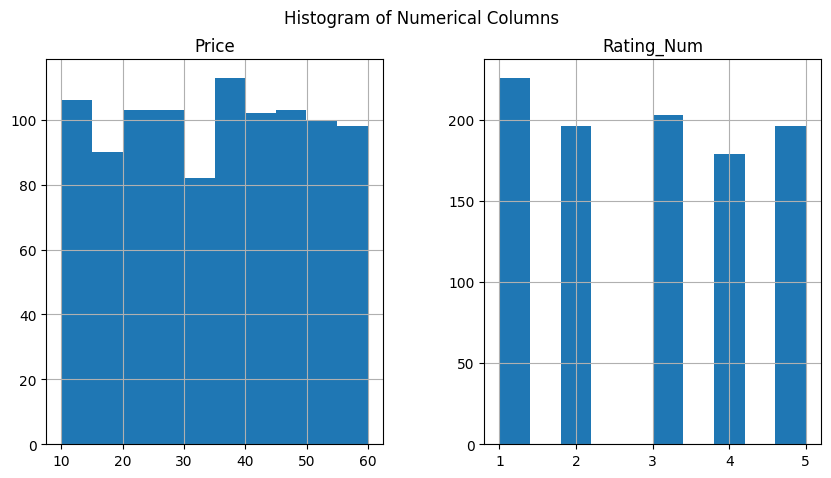

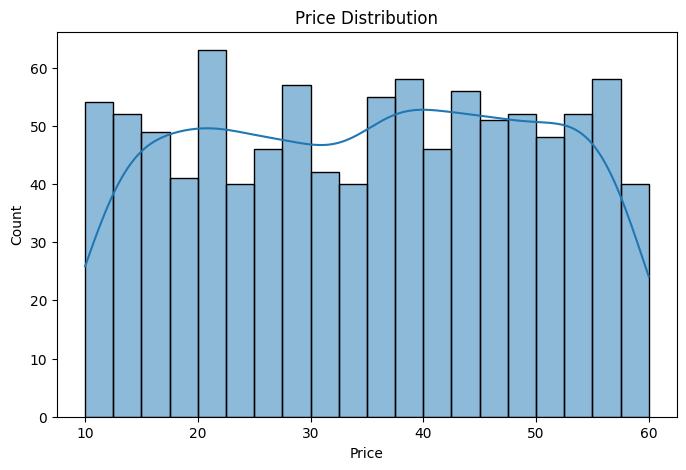

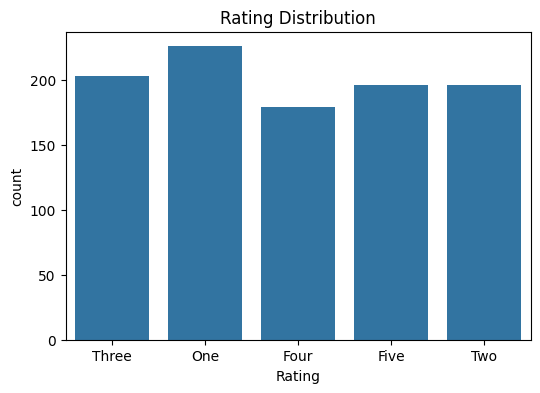

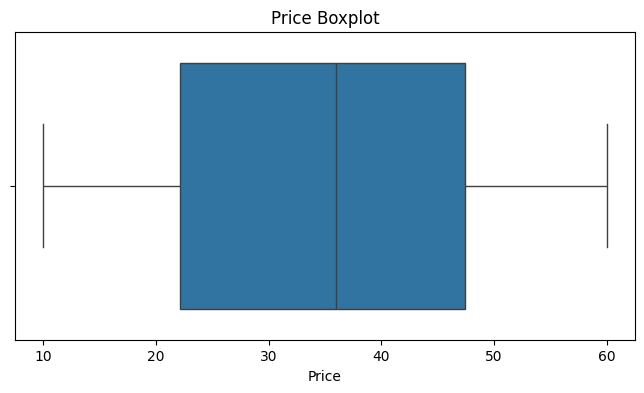

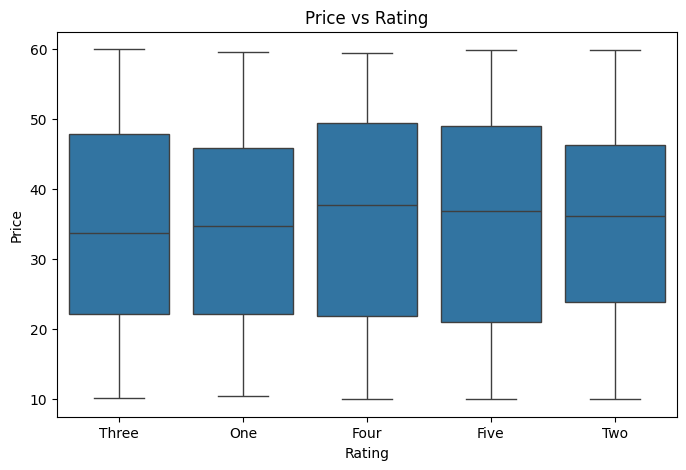

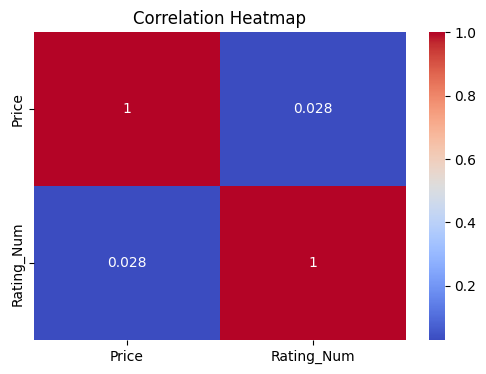


Duplicate Rows: 0

Number of Price Outliers: 0

Average Price by Rating:
Rating
Five     35.374490
Four     36.093296
One      34.561195
Three    34.692020
Two      34.810918
Name: Price, dtype: float64

EDA Completed Successfully!


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("books.xlsx")

print("\nDataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nFirst 5 Rows:")
print(df.head())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSummary:")
print(df.describe(include='all'))

df['Price'] = (
    df['Price']
    .str.replace('Â£', '', regex=False)
    .astype(float)
)

rating_map = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}

df['Rating_Num'] = df['Rating'].map(rating_map)

num_cols = df.select_dtypes(include=['int64', 'float64']).columns

print("\nNumerical Columns:")
print(num_cols)

df[num_cols].hist(figsize=(10,5))
plt.suptitle("Histogram of Numerical Columns")
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(df['Price'], bins=20, kde=True)
plt.title("Price Distribution")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x='Rating', data=df)
plt.title("Rating Distribution")
plt.show()

plt.figure(figsize=(8,4))
sns.boxplot(x=df['Price'])
plt.title("Price Boxplot")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x='Rating', y='Price', data=df)
plt.title("Price vs Rating")
plt.show()

corr = df[num_cols].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()
print("\nDuplicate Rows:", df.duplicated().sum())

Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Price'] < lower) | (df['Price'] > upper)]

print("\nNumber of Price Outliers:", len(outliers))

print("\nAverage Price by Rating:")
print(df.groupby('Rating')['Price'].mean())

print("\nEDA Completed Successfully!")
